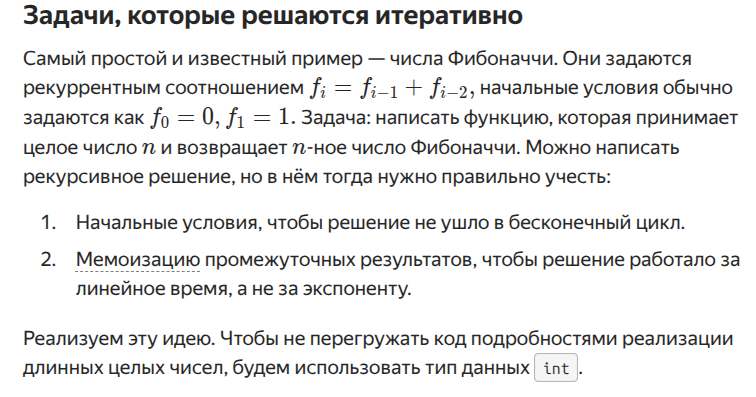

In [ ]:
def get_n_fib(n, mem_sum = {}):
    
    if n in mem_sum:
        return mem_sum[n]

    if n <= 1:
        return n
    
    mem_sum[n] = get_n_fib(n - 1) + get_n_fib(n - 2)
    return mem_sum[n]


In [7]:
get_n_fib(20)

6765

In [8]:
# Всего этого можно избежать, если написать простое итеративное решение.

In [15]:
def nth_fibonacci(n):
    if n <= 1:
        return n
    previous, current = 0, 1
    for _ in range(n - 1):
        previous, current = current, previous + current
    return current

In [16]:
nth_fibonacci(100)

354224848179261915075

In [12]:
def nth_fibonacci(n):
    if n <= 1:
        return n
    
    curr, prev = 1, 0
    for _ in range(n - 1):
        curr, prev = curr + prev, curr
    return curr


In [13]:
# 0 1 1 2 3 5
nth_fibonacci(3)

2

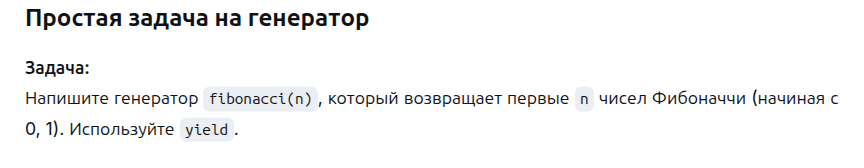

In [106]:
def fibonacci(n):
    prev, curr = 0, 1

    for _ in range(n):
        yield curr
        prev, curr = curr, curr + prev

In [107]:
gen = fibonacci(6)
print(next(gen))
print(next(gen))
print(next(gen))
print(next(gen))
print(next(gen))
print(next(gen))

1
1
2
3
5
8


In [108]:
def gen1():
    yield 1
    yield 2

def gen2():
    # без yield from пришлось бы писать for x in gen1(): yield x
    yield from gen1()
    yield 3

list(gen2())  # [1, 2, 3]

[1, 2, 3]

In [109]:
def subgen():
    yield 1
    yield 2
    return "done"

def main():
    result = yield from subgen()
    print(result)  # выведет "done"

print(list(main()))       # [1, 2] – значения из subgen

done
[1, 2]


In [ ]:
"""
Функция распаковать(строка s):
    стек = пустой стек          // будем хранить пары (строка_перед_скобкой, число_повторов)
    текущая_строка = ""
    текущее_число = 0

    Для каждого символа c в s:
        Если c - цифра (от '0' до '9'):
            текущее_число = текущее_число * 10 + (преобразовать c в число)
        
        Иначе если c == '(':
            // Сохраняем текущее состояние в стек
            положить в стек (текущая_строка, текущее_число)
            // Сбрасываем для новой группы
            текущая_строка = ""
            текущее_число = 0
        
        Иначе если c == ')':
            // Извлечь предыдущее состояние
            (предыдущая_строка, повтор) = извлечь из стека
            // Повторить текущую_строку `повтор` раз
            текущая_строка = предыдущая_строка + текущая_строка * повтор
        
        Иначе (c - буква):
            // Добавляем букву к текущей строке
            текущая_строка = текущая_строка + c

    Вернуть текущая_строка
"""

In [ ]:
"a2(bc2(d))"
# stack = [(a, 2), (bc, 2)]
"""
Алгоритм развёртки
1. Дошли до закрывающией скобки после d
2. Берём последний элемент в стеке - (bc, 2)
3. Формируем строку по правилу:
    1. stack[-1][1] * str_in_brackets, где stack[-1][1] = 2, str_in_brackets = d
    2. получаем строку (curr_str) - dd
    3. добавляем к строке элементы, которые были до кол-ва повторов:
        str_in_brackets = stack[-1][0] + str_in_brackets
        str_in_brackets == bcdd
    4. Удаляем последний элемент из стека stack.pop()
4. Далее идём по алгоритму
5. Доходим до последней ")"
6. Формируем строку по правилу:
    1. stack[-1][1] * str_in_brackets, где stack[-1][1] = 2, str_in_brackets = bcdd
    2. получаем строку (curr_str) - bcddbcdd
    3. добавляем к строке элементы, которые были до кол-ва повторов:
        str_in_brackets = stack[-1][0] + str_in_brackets
        curr_str = abcddbcdd
    4. Удаляем последний элемент из стека stack.pop()
7. Если после stack.pop() стек stack пустой, то:
    result_str += str_in_brackets
    str_in_brackets = ""


"a2(bc2(d))" - "abcddbcdd"
"""

In [92]:
"aaa2(bc2(d))"

"a2(bc)"
""""
1. 
result_str - a
2. 
result_str - a
number_str - 2

"""

def unwrape(s):

    numbers = set([str(i) for i in range(1, 10)])
    brackets_list = ["[","]"]
    brackets = set(brackets_list)

    stack = [] # []
    number_str = ''
    str_in_brackets = ''
    result_str = ''

    for i, el in enumerate(s):

        # Переход с числа на букву (мгновенная развёртка)
        if el not in numbers | brackets and s[i-1] in numbers:
            result_str += int(number_str) * el
            number_str = ''
        elif el not in numbers | brackets and not stack:
            result_str += el
        elif el in numbers:
            number_str += el 
        # Переход с числа на ПЕРВУЮ скобку, начальная инициализация, стек пуст
        elif el == brackets_list[0] and s[i-1] in numbers and not stack:
            stack.append((result_str, number_str))
            number_str = ''
        # собираем строку внутри скобки
        elif stack and el not in numbers | brackets:
            str_in_brackets += el
        # наполняем стек внутри скобок (увеличение вложенности)
        elif stack and el == brackets_list[0]:
            stack.append((str_in_brackets, number_str))
            number_str = ''
            str_in_brackets = ''
        # наткнулись на ")" - начинаем развёртку
        elif el == brackets_list[1]:
            stack_upper = stack.pop()
            str_in_brackets = stack_upper[0] + str_in_brackets * int(stack_upper[1])
            result_str = str_in_brackets


    return result_str                           


In [93]:
s = "3[a]2[bc]"
unwrape(s)

'aaaaaabcaaabc'

In [76]:
"aaa2(bc2(d))"

"a2(bc)"
""""
1. 
result_str - a
2. 
result_str - a
number_str - 2

"""

numbers = set([str(i) for i in range(1, 10)])
brackets_list = ["(",")"]
brackets = set(brackets_list)

def unwrape(s):

    stack = [] # []
    number_str = ''
    str_in_brackets = ''
    result_str = ''

    for i, el in enumerate(s):

        # Переход с числа на букву (мгновенная развёртка)
        if el not in numbers | brackets and s[i-1] in numbers:
            result_str += int(number_str) * el
            number_str = ''
        elif el not in numbers | brackets and not stack:
            result_str += el
        elif el in numbers:
            number_str += el 
        # Переход с числа на ПЕРВУЮ скобку, начальная инициализация, стек пуст
        elif el == brackets_list[0] and s[i-1] in numbers and not stack:
            stack.append((result_str, number_str))
            number_str = ''
        # собираем строку внутри скобки
        elif stack and el not in numbers | brackets:
            str_in_brackets += el
        # наполняем стек внутри скобок (увеличение вложенности)
        elif stack and el == brackets_list[0]:
            stack.append((str_in_brackets, number_str))
            number_str = ''
            str_in_brackets = ''
        # наткнулись на ")" - начинаем развёртку
        elif el == brackets_list[1]:
            stack_upper = stack.pop()
            str_in_brackets = stack_upper[0] + str_in_brackets * int(stack_upper[1])
            result_str = str_in_brackets
        # Алгоритм развёртки стека (тогда станет понятна его структура)

        # # Переход со скобки на букву
        # elif:
        # else:
        #     result_str += el

    return result_str                           

s = "2a"
print(unwrape(s))     

aa


In [77]:
s = "aaa2(bc)"
unwrape(s)

'aaabcbc'

In [78]:
s = "a2(bc)"
assert unwrape(s) == "abcbc"

In [79]:
s = "aaa"
assert unwrape(s) == "aaa"

In [80]:
s = "2a"
print(unwrape(s))
assert unwrape(s) == "aa"

aa


In [81]:
s = "2a2a"
assert unwrape(s) == "aaaa"

In [82]:
s = "3db"
assert unwrape(s) == "dddb"

In [83]:
s = "a2(a2(bc))"
assert unwrape(s) == "aabcbcabcbc"

In [84]:
s = "a2(a2(bc))3db"
assert unwrape(s) == "aabcbcabcbcdddb"

In [94]:
# Красивый и локоничный вариант

In [14]:
def decode_string(s: str) -> str:
    stack = []          # храним (строка_перед_скобкой, число_повторов)
    current = ""        # текущая распакованная строка на данном уровне
    num = 0             # текущее накопленное число

    for ch in s:
        if ch.isdigit():
            num = num * 10 + int(ch)
        elif ch == '(':
            # сохраняем текущее состояние в стек и начинаем новый уровень
            stack.append((current, num))
            current = ""
            num = 0
        elif ch == ')':
            # закрываем скобку: извлекаем предыдущие строку и число
            prev_str, repeat = stack.pop()
            current = prev_str + current * repeat
        else:   # буква
            if num > 0:
                # число перед буквой без скобки
                current += ch * num
                num = 0
            else:
                current += ch
    return current

In [15]:
decode_string("a2(a2(bc))3db")

'aabcbcabcbcdddb'